<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [1]:
# Install the necessary libraries
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2: Load the Dataset


In [2]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv("../data/data.csv")

# Display the first few rows to understand the structure of the dataset
df.head()

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,0,0,0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,2,2,2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,3,3,3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,4,4,4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


In [3]:
# df.to_csv("data.csv")

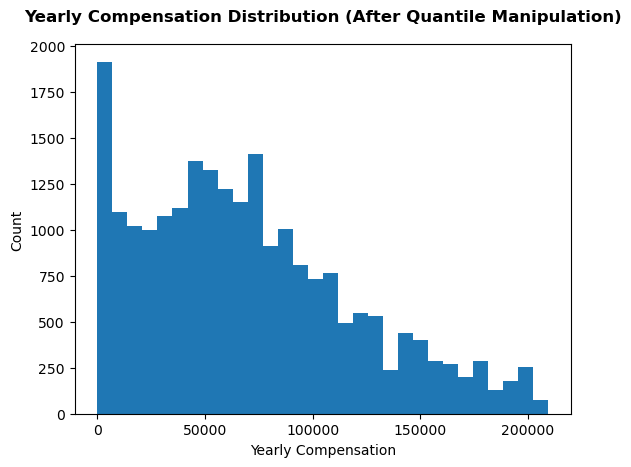

In [4]:
## Write your code here
(df.ConvertedCompYearly
	.loc[
	df.ConvertedCompYearly < df.ConvertedCompYearly.quantile(0.95, interpolation="higher")
		]
	.plot.hist(bins=30,
			   ylabel="Count",
			   xlabel="Yearly Compensation")
)

plt.title(label="Yearly Compensation Distribution (After Quantile Manipulation)", y=1.04, fontweight=720);

<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [5]:
## Write your code here
df.ConvertedCompYearly.loc[df.Employment == "Employed, full-time"].median()
df.ConvertedCompYearly.median()

65000.0

<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



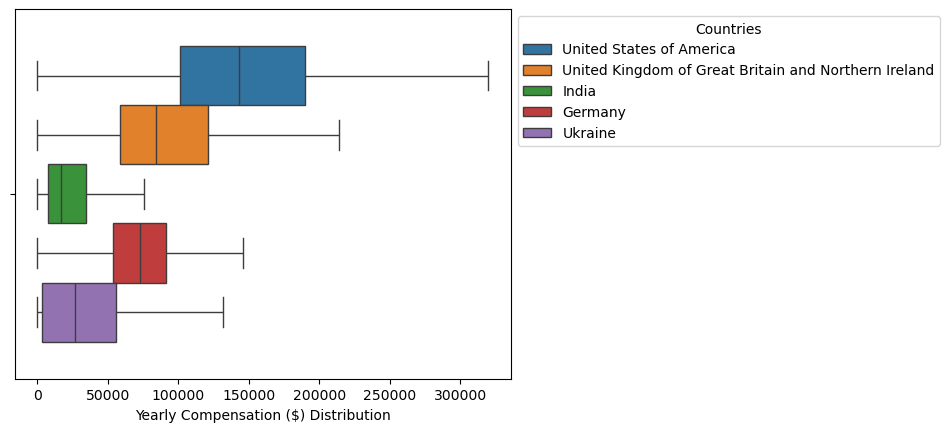

In [6]:
## Write your code here
df_new = df.loc[df["Country"].isin(df.Country.value_counts().head().index)]

sns.boxplot(data=df_new,
			x="ConvertedCompYearly",
			hue="Country",
			fill=True,
			showfliers=False)

plt.legend(title="Countries", bbox_to_anchor=(1, 1))
plt.xlabel("Yearly Compensation ($) Distribution");

<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


In [7]:
q1, q3 = df.ConvertedCompYearly.quantile([0.25, 0.75], interpolation="linear")

iqr = (q3 - q1) * 1.5
upper = q3 + iqr
lower = q1 - iqr

mask= (df.ConvertedCompYearly > lower) | (df.ConvertedCompYearly < upper)
df_within_iqr = df[mask]
df_within_iqr.head()

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
72,72,72,72,73,I am a developer by profession,18-24 years old,"Employed, full-time;Student, full-time;Indepen...","Hybrid (some remote, some in-person)",Apples,Hobby;School or academic work;Professional dev...,...,65.0,100.0,100.0,100.0,50.0,90.0,Too long,Easy,7322.0,10.0
374,374,374,374,375,"I am not primarily a developer, but I write co...",25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;School or academic work;Professional dev...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,30074.0,NaN
379,379,379,379,380,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Bootstrapping a business,...,0.0,0.0,0.0,0.0,0.0,0.0,Too long,Difficult,91295.0,10.0
385,385,385,385,386,I am a developer by profession,35-44 years old,"Independent contractor, freelancer, or self-em...",Remote,Apples,Hobby,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,53703.0,NaN
389,389,389,389,390,I am a developer by profession,25-34 years old,"Employed, full-time;Student, part-time",Remote,Apples,Hobby;School or academic work,...,20.0,30.0,5.0,20.0,10.0,5.0,Too long,Easy,110000.0,10.0


<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


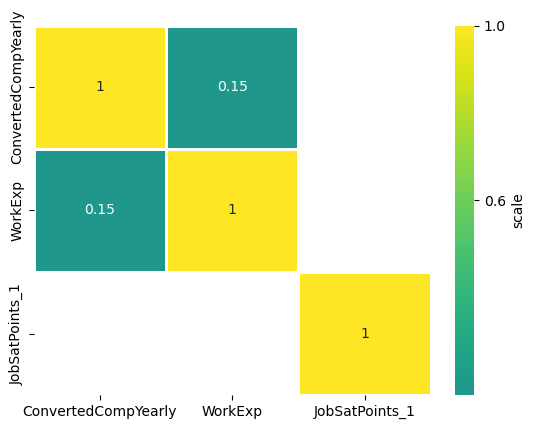

In [8]:
## Write your code here
corr = df_within_iqr[["ConvertedCompYearly", "WorkExp", "JobSatPoints_1"]].corr()

sns.heatmap(data=corr,
			mask = corr.abs() < 0.1,
			ec="1.0",
			lw=1,
			center=0.1,
			annot=True,
			cmap="viridis",
			cbar=True,
			cbar_kws=dict(ticks=[0.1, 0.6, 1.0], label="scale"),
			snap=True);

<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


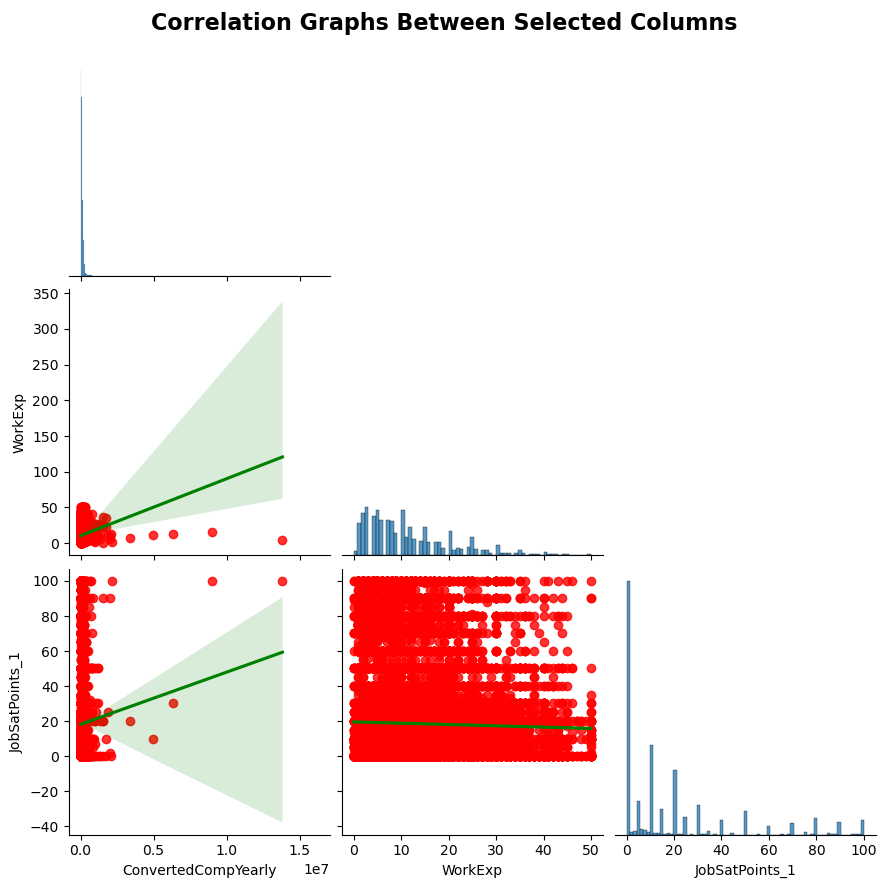

In [9]:
## Write your code here
g = sns.pairplot(
				data=df,
				kind="reg",
				vars=["ConvertedCompYearly", "WorkExp", "JobSatPoints_1"],
				corner=True,
				height=3,
				plot_kws=dict(scatter_kws=dict(color="red", marker="d"),
							  line_kws=dict(color="green")
							 )
)

g.fig.suptitle(
    "Correlation Graphs Between Selected Columns",
    fontsize=16,
    fontweight="bold",
    fontfamily="sans-serif"
);

<h3>Summary</h3>


In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
